In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [ ]:
from sklearn.datasets import load_iris
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_names'] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_names       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.shape

(150, 6)

In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
target_names,0


In [ ]:
# Option 2: Use 'agg' for custom aggregations
df[['sepal length (cm)', 'sepal width (cm)']].agg(['mean', 'std'])

,sepal length (cm),sepal width (cm)
mean,5.843333,3.057333
std,0.828066,0.435866


In [ ]:
# Option 3: Group and aggregate data
df.groupby('target_names')[['sepal length (cm)', 'sepal width (cm)']].agg(['mean', 'std'])

sepal length (cm)           sepal width (cm)          
                          mean       std             mean       std
target_names                                                       
setosa                   5.006  0.352490            3.428  0.379064
versicolor               5.936  0.516171            2.770  0.313798
virginica                6.588  0.635880            2.974  0.322497

In [ ]:
df['species'] = pd.value_counts(df['target_names'])
df


<ipython-input-31-b8280db695f3>:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  df['species'] = pd.value_counts(df['target_names'])


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,species
0,5.1,3.5,1.4,0.2,0,setosa,NaN
1,4.9,3.0,1.4,0.2,0,setosa,NaN
2,4.7,3.2,1.3,0.2,0,setosa,NaN
3,4.6,3.1,1.5,0.2,0,setosa,NaN
4,5.0,3.6,1.4,0.2,0,setosa,NaN
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica,NaN
146,6.3,2.5,5.0,1.9,2,virginica,NaN
147,6.5,3.0,5.2,2.0,2,virginica,NaN
148,6.2,3.4,5.4,2.3,2,virginica,NaN


In [ ]:
#split data into x and y
df.iloc[:,1:5]


,sepal width (cm),petal length (cm),petal width (cm),target
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0
...,...,...,...,...
145,3.0,5.2,2.3,2
146,2.5,5.0,1.9,2
147,3.0,5.2,2.0,2
148,3.4,5.4,2.3,2


In [ ]:
x=df.iloc[:,1:5]
y=df['target']

In [ ]:
x

,sepal width (cm),petal length (cm),petal width (cm),target
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0
...,...,...,...,...
145,3.0,5.2,2.3,2
146,2.5,5.0,1.9,2
147,3.0,5.2,2.0,2
148,3.4,5.4,2.3,2


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
#display column names
columns=list(df.columns)
columns

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)',
 'target',
 'target_names',
 'species']

In [ ]:
#split entire data in test and train
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)


In [ ]:
x_train

,sepal width (cm),petal length (cm),petal width (cm),target
137,3.1,5.5,1.8,2
84,3.0,4.5,1.5,1
27,3.5,1.5,0.2,0
127,3.0,4.9,1.8,2
132,2.8,5.6,2.2,2
...,...,...,...,...
9,3.1,1.5,0.1,0
103,2.9,5.6,1.8,2
67,2.7,4.1,1.0,1
117,3.8,6.7,2.2,2


In [ ]:
y_test

,target
114,2
62,1
33,0
107,2
7,0
100,2
40,0
86,1
76,1
71,1


In [ ]:
x_test

,sepal width (cm),petal length (cm),petal width (cm),target
114,2.8,5.1,2.4,2
62,2.2,4.0,1.0,1
33,4.2,1.4,0.2,0
107,2.9,6.3,1.8,2
7,3.4,1.5,0.2,0
100,3.3,6.0,2.5,2
40,3.5,1.3,0.3,0
86,3.1,4.7,1.5,1
76,2.8,4.8,1.4,1
71,2.8,4.0,1.3,1


In [ ]:
#building decision tree calssifier using entropy criteria
dt=DecisionTreeClassifier(criterion='entropy',random_state=0)
dt

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
#plot decisiontree classifier
dt.fit(x_train,y_train)


DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
#plot
y_pred=dt.predict(x_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

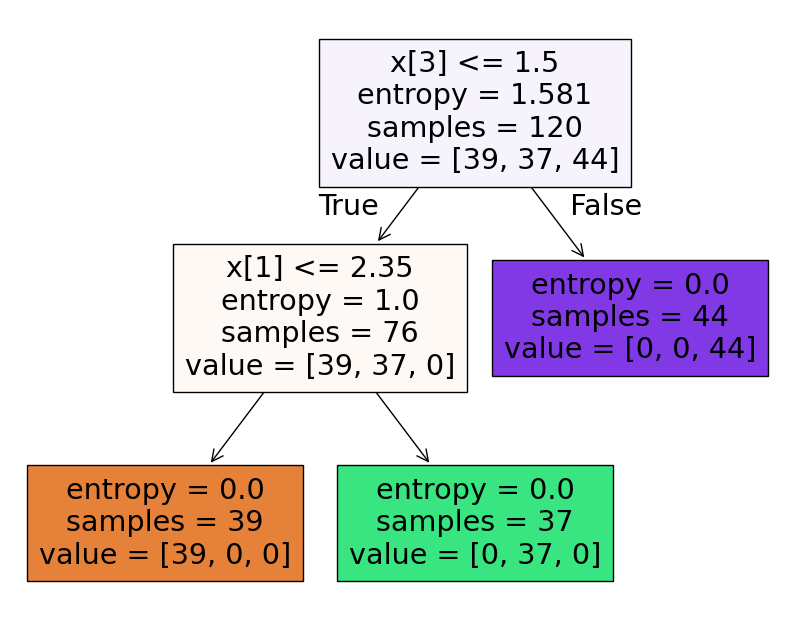

In [ ]:
#decision tree plot
from sklearn.tree import plot_tree
plt.figure(figsize=(10,8))
plot_tree(dt,filled=True)
plt.show()

[Text(0.6, 0.8333333333333334, 'petal width (cm) <= 1.5\nentropy = 1.581\nsamples = 120\nvalue = [39, 37, 44]\nclass = virginica'),
 Text(0.4, 0.5, 'sepal width (cm) <= 2.35\nentropy = 1.0\nsamples = 76\nvalue = [39, 37, 0]\nclass = setosa'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'entropy = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = setosa'),
 Text(0.6, 0.16666666666666666, 'entropy = 0.0\nsamples = 37\nvalue = [0, 37, 0]\nclass = versicolor'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 44\nvalue = [0, 0, 44]\nclass = virginica'),
 Text(0.7, 0.6666666666666667, '  False')]

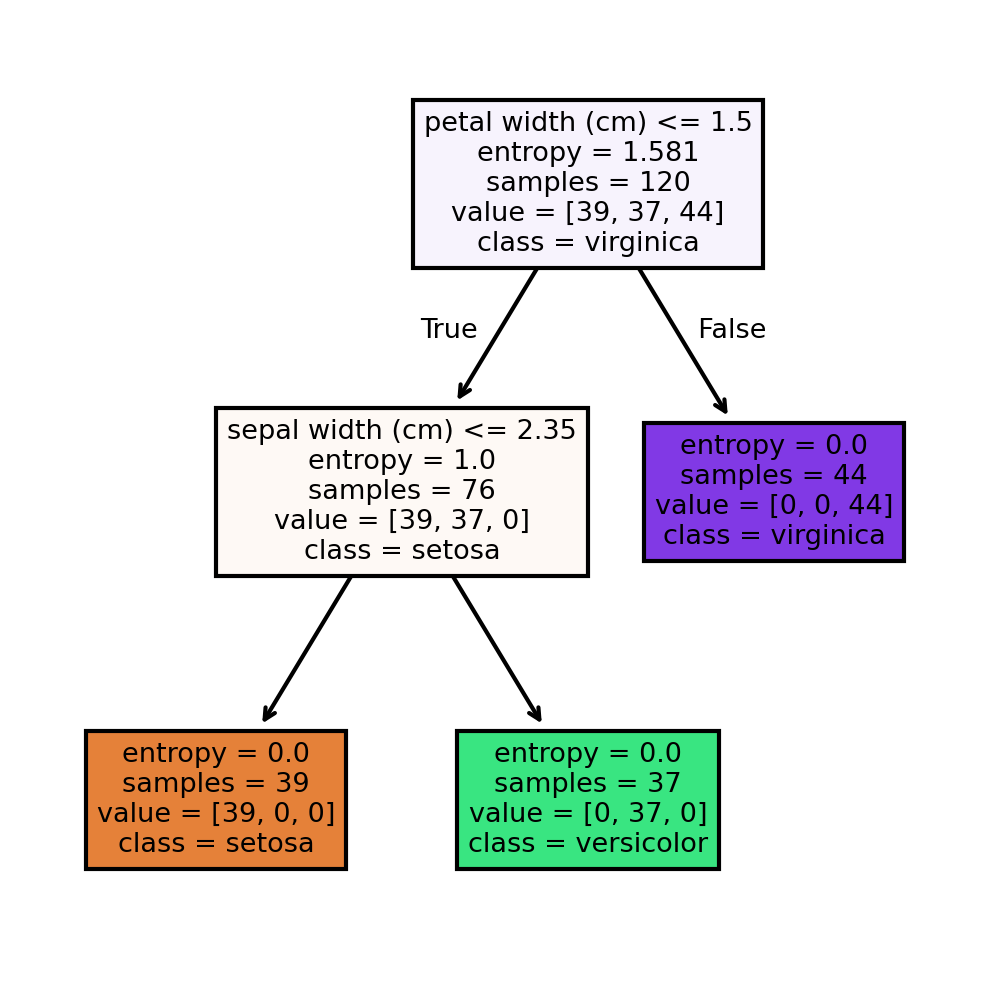

In [ ]:
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa','versicolor','virginica']
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=300)
plot_tree(dt,
         feature_names=fn,
         class_names=cn,
         filled=True)


In [ ]:
#predicted on the test data
y_pred=dt.predict(x_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [ ]:
#series
y_pred=pd.Series(y_pred)
y_pred.value_counts()

,count
1,13
0,11
2,6


In [ ]:
#crosstabs
pd.crosstab(y_test,y_pred)

col_0,0,1,2
target,,,
0,2,3,1


In [ ]:
#Accuracy
dt_acc=accuracy_score(y_test,y_pred)
dt_acc

1.0

In [ ]:
#building decsion tree calssifier (cart) using gini cretria
dt1=DecisionTreeClassifier(criterion='gini',random_state=0)
dt1

DecisionTreeClassifier(random_state=0)

In [ ]:
dt1_gini=dt1.fit(x_train,y_train)
dt1_gini.score(x_train,y_train)
dt1_gini.score(x_test,y_test)

1.0

In [ ]:
dt1_gini=dt1.fit(x_train,y_train)
dt1_gini


DecisionTreeClassifier(random_state=0)

In [ ]:
#predicted and computing the accuracy
y_pred=dt1.predict(x_test)
y_pred


array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [ ]:
y_pred=dt1_gini.predict(x_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [ ]:
np.mean(y_pred==y_test)

1.0

In [ ]:
#decision tree regression example
from sklearn.tree import DecisionTreeRegressor
import numpy as np

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,species
0,5.1,3.5,1.4,0.2,0,setosa,NaN
1,4.9,3.0,1.4,0.2,0,setosa,NaN
2,4.7,3.2,1.3,0.2,0,setosa,NaN
3,4.6,3.1,1.5,0.2,0,setosa,NaN
4,5.0,3.6,1.4,0.2,0,setosa,NaN
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica,NaN
146,6.3,2.5,5.0,1.9,2,virginica,NaN
147,6.5,3.0,5.2,2.0,2,virginica,NaN
148,6.2,3.4,5.4,2.3,2,virginica,NaN


In [ ]:
array=df.values
x=array[:,0:4]
y=array[:,4]

In [ ]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3.0, 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5.0, 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5.0, 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3.0, 1.4, 0.1],
       [4.3, 3.0, 1.1, 0.1],
       [5.8, 4.0, 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1.0, 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5.0, 3.0, 1.6, 0.2],
       [5.0, 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=object)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)


In [ ]:
x_train

array([[6.4, 3.1, 5.5, 1.8],
       [5.4, 3.0, 4.5, 1.5],
       [5.2, 3.5, 1.5, 0.2],
       [6.1, 3.0, 4.9, 1.8],
       [6.4, 2.8, 5.6, 2.2],
       [5.2, 2.7, 3.9, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6.0, 2.7, 5.1, 1.6],
       [5.9, 3.0, 4.2, 1.5],
       [5.8, 2.6, 4.0, 1.2],
       [6.8, 3.0, 5.5, 2.1],
       [4.7, 3.2, 1.3, 0.2],
       [6.9, 3.1, 5.1, 2.3],
       [5.0, 3.5, 1.6, 0.6],
       [5.4, 3.7, 1.5, 0.2],
       [5.0, 2.0, 3.5, 1.0],
       [6.5, 3.0, 5.5, 1.8],
       [6.7, 3.3, 5.7, 2.5],
       [6.0, 2.2, 5.0, 1.5],
       [6.7, 2.5, 5.8, 1.8],
       [5.6, 2.5, 3.9, 1.1],
       [7.7, 3.0, 6.1, 2.3],
       [6.3, 3.3, 4.7, 1.6],
       [5.5, 2.4, 3.8, 1.1],
       [6.3, 2.7, 4.9, 1.8],
       [6.3, 2.8, 5.1, 1.5],
       [4.9, 2.5, 4.5, 1.7],
       [6.3, 2.5, 5.0, 1.9],
       [7.0, 3.2, 4.7, 1.4],
       [6.5, 3.0, 5.2, 2.0],
       [6.0, 3.4, 4.5, 1.6],
       [4.8, 3.1, 1.6, 0.2],
       [5.8, 2.7, 5.1, 1.9],
       [5.6, 2.7, 4.2, 1.3],
       [5.6, 2

In [ ]:
y_train

array([2, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0, 0, 1, 2, 2, 2, 2, 1, 2,
       1, 1, 2, 2, 2, 2, 1, 2, 1, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 1, 0, 0,
       1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2,
       0, 0, 2, 0, 0, 0, 1, 2, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 2, 1, 2, 1,
       0, 2, 0, 2, 0, 0, 2, 0, 2, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 0, 1,
       1, 1, 1, 0, 0, 0, 2, 1, 2, 0], dtype=object)

In [ ]:
model=DecisionTreeRegressor()
model.fit(x_train,y_train)


DecisionTreeRegressor()

In [ ]:
#find the accuracy
model.score(x_test,y_test)

1.0

In [ ]:
#plot
from sklearn import tree
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
wine = load_wine()
Xtrain, Xtest, Ytrain, Ytest = train_test_split(wine.data, wine.target, test_size=0.3)
clf = tree.DecisionTreeClassifier(criterion="entropy")
clf = clf.fit(Xtrain, Ytrain)
score = clf.score(Xtest, Ytest)
print(score)

0.9444444444444444


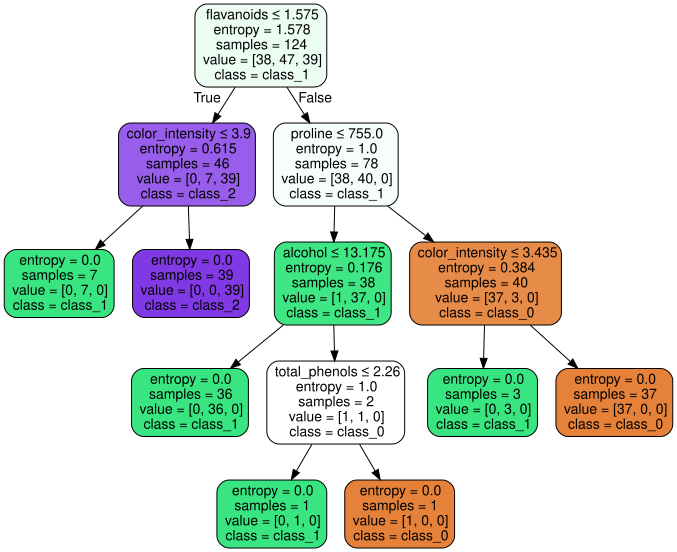

In [ ]:
#visulazition
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=wine.feature_names, class_names=wine.target_names, filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph